# 2.1 Transit light curve analysis of WASP-12b 

### Universidad de La Laguna Exo & Exo 2025-2026 exercise 2

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 16.4.2026

## Initialisation

In [1]:
import math as mt
import pandas as pd
import warnings
import seaborn as sb

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, array, median, seterr, floor, percentile
from numpy.random import seed, permutation
from astropy.table import Table
from corner import corner

from pytransit import TransitLPF

seterr('ignore')
seed(0)

### Read in the data

First we need to read in the light curve stored in ``wasp-12b_181227_chromatic_k.fits``. The file has light curves for a single transit observed simultaneously in four passbands (g, r, i, and z_s), but we keep things simple and use only the r-band data. 

In our case, the photometry is saved as binary table extensions in the fits file, one extension per passband. To get the r-band data, we need to read the third HDU of the fits file (the first is the primary HDU, the second the first extension, etc.).

We start the same way as with the RV data and take a look at our data and try plotting it.

In [2]:
tb = Table.read('data/wasp-12b_181227_chromatic_k.fits', 2)
tb[:5]

time_bjd,flux,flux_rel,flux_trg,flux_ref,baseline,model
float64,float64,float64,float64,float64,float64,float64
2458480.557361179,1.0001350941062013,1.016282780690799,1.0234186998514527,1.0070215881802143,1.0161455054219737,1.0
2458480.558397079,1.0000222850175708,1.0167163747091499,1.0256873377854854,1.0088234667007323,1.0166937176717874,1.0
2458480.5587828704,0.999633046547194,1.0162828378132795,1.0244264276468822,1.0080131136044028,1.016655903207277,1.0
2458480.5594445122,1.0004227218395325,1.0169303171289636,1.0232086525273774,1.0061738108232814,1.016500620116942,1.0
2458480.5602084063,0.9981259684100012,1.0146302762017558,1.021813766379826,1.0070799091516973,1.0165352954577924,1.0


Now, we can assume the time data is stored in the ``time_bjd`` column and the flux the ``flux`` column. In general, if you'd see a file like this, you should check the file's documentation (if such exists) what column is what, or ask the person who created the file.

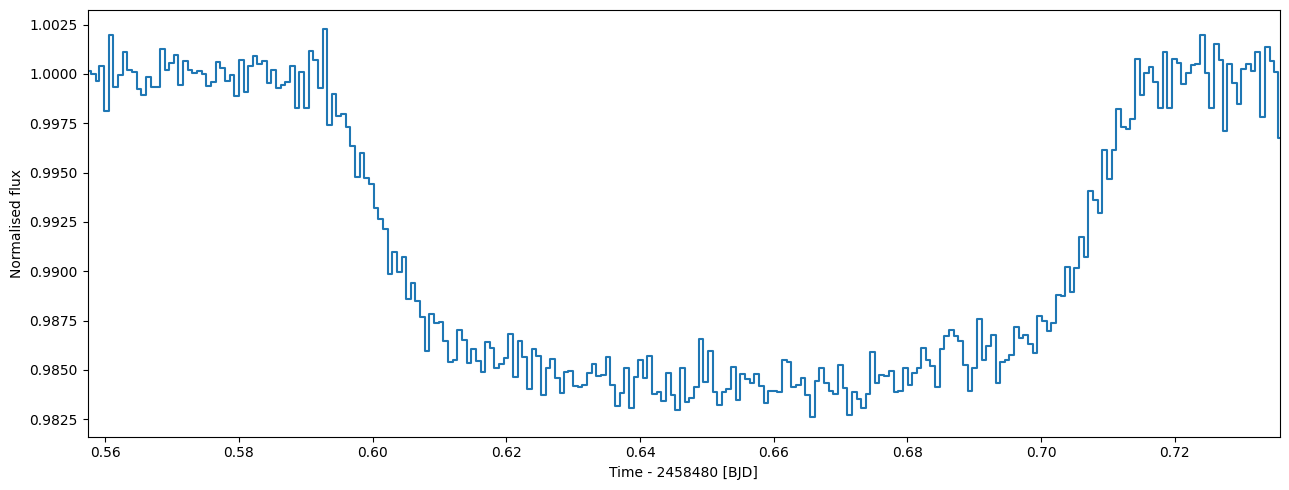

In [3]:
tref = floor(tb['time_bjd'].mean())
fig, ax = subplots(figsize=(13,5), sharey=True)
ax.plot(tb['time_bjd'] - tref, tb['flux'], drawstyle='steps-mid')
setp(ax, xlabel=f"Time - {tref:.0f} [BJD]", ylabel='Normalised flux', xlim=tb['time_bjd'][[0,-1]]-tref)
fig.tight_layout()

## Parameter estimation

First, we create an instance of the log posterior function with the redmost light curve data.

Next, we run the *DE* optimiser for ``de_iter`` iterations to clump the parameter vector population close to the global posterior maximum, use the *DE* population to initialise the *emcee* sampler, and run the sampler for ``mc_iter`` iterations to obtain a posterior sample.

### Initialise the LPF and set the priors

In [4]:
lpf = TransitLPF('WASP-12b', 'r', tb['time_bjd'], tb['flux'])
lpf.ps

[  0 |G| tc             N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p              N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

In [5]:
lpf.set_prior('tc', 'NP', 2458480.65, 0.02)
lpf.set_prior('p', 'NP', 1.0914201, 1.1e-09)

In [6]:
lpf.ps

[  0 |G| tc             N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p              N(μ = 1.0914201, σ = 1.1e-09)            [    0.00 ..      inf],
   2 |G| rho            U(a = 0.1, b = 25.0)                     [    0.00 ..      inf],
   3 |G| b              U(a = 0.0, b = 1.0)                      [    0.00 ..     1.00],
   4 |P| k2             U(a = 0.0025, b = 0.04)                  [    0.00 ..      inf],
   5 |P| q1_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   6 |P| q2_r           U(a = 0, b = 1)                          [    0.00 ..     1.00],
   7 |L| wn_loge_0      U(a = -4, b = 0)                         [    -inf ..      inf]]

Global optimisation:   0%|          | 0/500 [00:00<?, ?it/s]

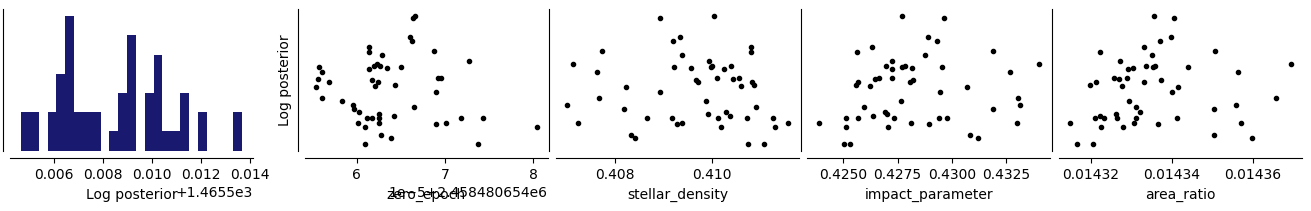

In [7]:
lpf.optimize_global(niter=500, npop=50)

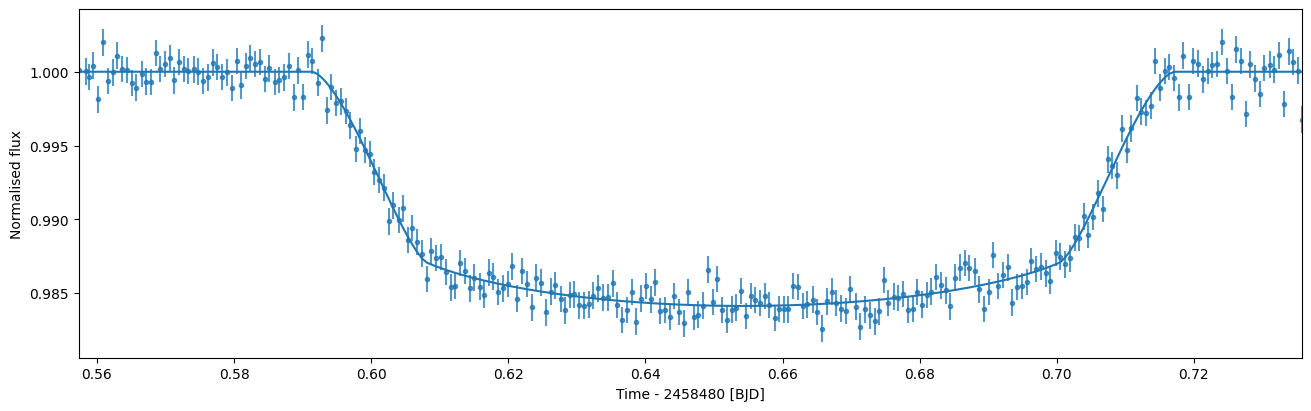

In [8]:
lpf.plot_light_curve();

In [9]:
lpf.sample_mcmc(5000, thin=20, repeats=2, label='MCMC sampling')

MCMC sampling:   0%|          | 0/2 [00:00<?, ?it/s]

Run 1/2:   0%|          | 0/5000 [00:00<?, ?it/s]

Run 2/2:   0%|          | 0/5000 [00:00<?, ?it/s]

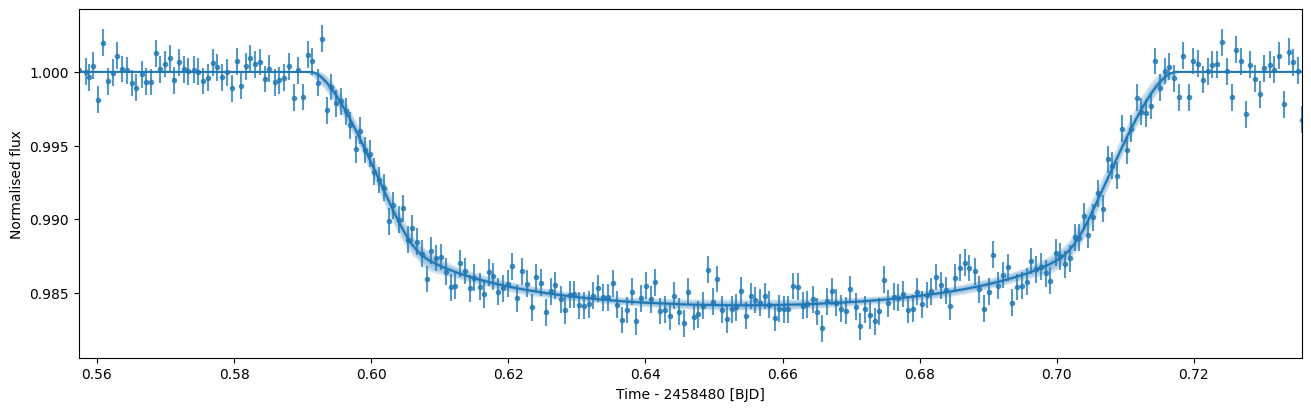

In [10]:
lpf.plot_light_curve('mc');

### Analysis: overview

The MCMC chains are now stored in ``lpf.sampler.chain``. Let's first have a look into how the chain populations evolved to see if we have any problems with our setup, whether we have converged to sample the true posterior distribution, and, if so, what was the burn-in time.

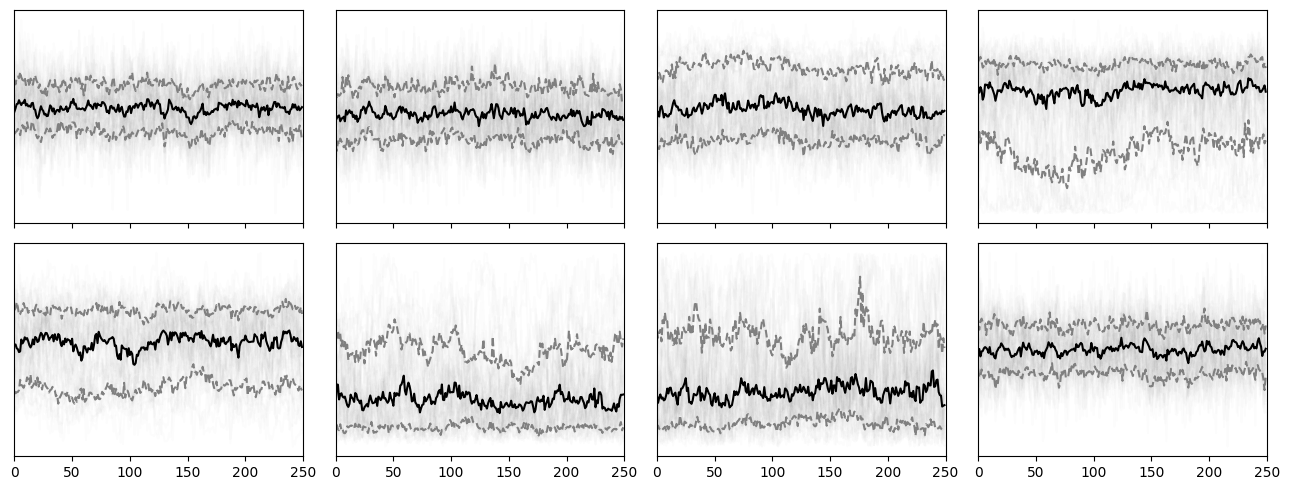

In [11]:
fig, axs = subplots(2,4, figsize=(13,5), sharex=True)
ls, lc = ['-','--','--'], ['k', '0.5', '0.5']
percs = [percentile(lpf.sampler.chain[:,:,i], [50,16,84], 0) for i in range(8)]
[axs.flat[i].plot(lpf.sampler.chain[:,:,i].T, 'k', alpha=0.01) for i in range(8)]
[[axs.flat[i].plot(percs[i][j], c=lc[j], ls=ls[j]) for j in range(3)] for i in range(8)]
setp(axs, yticks=[], xlim=[0,5000//20])
fig.tight_layout()

Ok, everything looks good. The 16th, 50th and 84th percentiles of the parameter vector population are stable and don't show any significant long-term trends. Now we can flatten the individual chains into one long chain ``fc`` and calculate the median parameter vector.

In [12]:
fc = lpf.sampler.chain.reshape([-1,lpf.sampler.chain.shape[-1]])
mp = median(fc, 0)

Let's also plot the model and the data to see if this all makes sense. To do this, we calculate the conditional distribution of flux using the posterior samples (here, we're using a random subset of samples, although this isn't really necessary), and plot the distribution median and it's median-centred 68%, 95%, and 99.7% central posterior intervals (corresponding approximately to 1, 2, and 3$\sigma$ intervals if the distribution is normal). 

In [13]:
flux_pr = lpf.flux_model(fc[permutation(fc.shape[0])[:1000]])
flux_pc = array(percentile(flux_pr, [50, 0.15,99.85, 2.5,97.5, 16,84], 0))

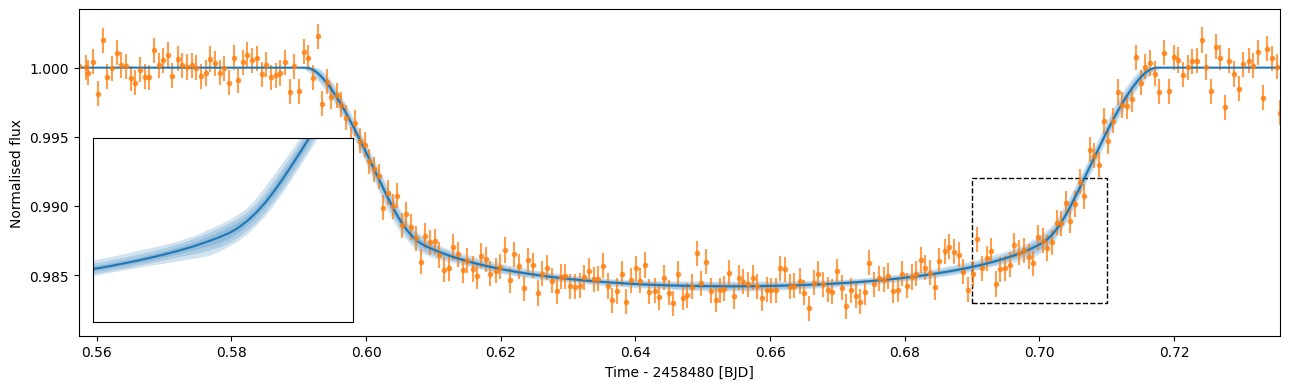

In [14]:
zx1,zx2,zy1,zy2 = 0.69,0.71, 0.983, 0.992
tref = floor(lpf.timea.min())
fig, ax = subplots(1,1, figsize=(13,4))
ax.errorbar(lpf.timea-tref, lpf.ofluxa, 10**mp[7], fmt='.', c='C1', alpha=0.75)
[ax.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
ax.plot(lpf.timea-tref, flux_pc[0], c='C0')
setp(ax, xlim=lpf.timea[[0,-1]]-tref, xlabel=f'Time - {tref:.0f} [BJD]', ylabel='Normalised flux')
fig.tight_layout()

az = fig.add_axes([0.075,0.18,0.20,0.46])
ax.add_patch(Rectangle((zx1,zy1),zx2-zx1,zy2-zy1,fill=False,edgecolor='k',lw=1,ls='dashed'))
[az.fill_between(lpf.timea-tref,*flux_pc[i:i+2,:],alpha=0.2,facecolor='C0') for i in range(1,6,2)]
setp(az, xlim=(zx1,zx2), ylim=(zy1,zy2), yticks=[], xticks=[])
az.plot(lpf.timea-tref, flux_pc[0], c='C0');

We could (should) also plot the residuals, but I've left them out from the plot for clarity. The plot looks fine, and we can continue to have a look at the parameter estimates.

## Analysis

We start the analysis by making a Pandas data frame ``df``, using the ``df.describe`` to gen an overview of the estimates, and plotting the posteriors for the most interesting parameters as violin plots.

In [15]:
pd.set_option('display.precision',4)
df = lpf.posterior_samples(derived_parameters=True)
df.describe()

,tc,p,rho,b,k2,q1_r,q2_r,wn_loge_0,k,a,inc,t14,t23
count,1.2500e+04,1.2500e+04,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000,12500.0000
mean,2.4585e+06,1.0914e+00,0.4378,0.3245,0.0139,0.3230,0.3383,-3.0412,0.1180,3.0186,1.4618,0.1258,0.0948
std,1.6064e-04,1.1291e-09,0.0372,0.1300,0.0005,0.1957,0.2336,0.0193,0.0019,0.0855,0.0456,0.0009,0.0026
min,2.4585e+06,1.0914e+00,0.3205,0.0002,0.0127,0.0454,0.0005,-3.1148,0.1126,2.7226,1.3595,0.1226,0.0873
25%,2.4585e+06,1.0914e+00,0.4095,0.2494,0.0136,0.1668,0.1544,-3.0545,0.1165,2.9543,1.4274,0.1251,0.0928
50%,2.4585e+06,1.0914e+00,0.4341,0.3637,0.0140,0.2716,0.2809,-3.0414,0.1183,3.0125,1.4498,0.1257,0.0945
75%,2.4585e+06,1.0914e+00,0.4679,0.4222,0.0143,0.4379,0.4779,-3.0281,0.1195,3.0887,1.4899,0.1264,0.0969
max,2.4585e+06,1.0914e+00,0.5327,0.5709,0.0151,0.9983,0.9998,-2.9680,0.1229,3.2250,1.5707,0.1297,0.1017


<Axes: >

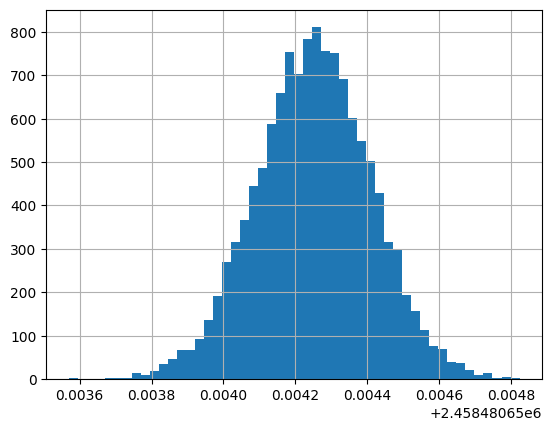

In [16]:
df.tc.hist(bins=50)

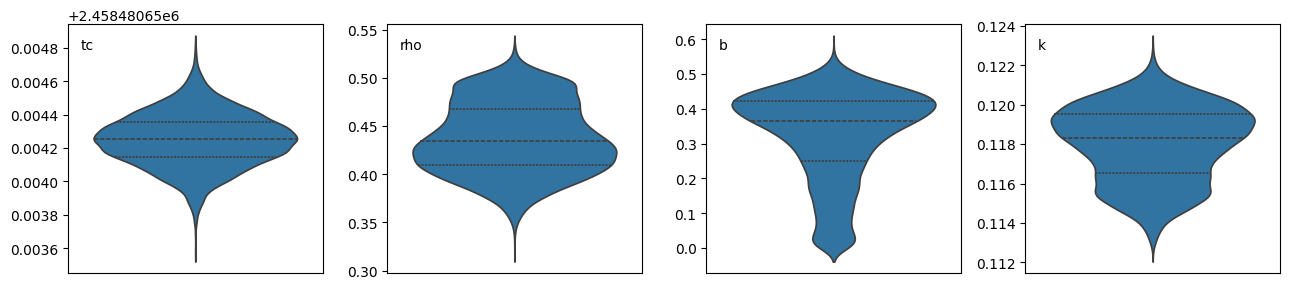

In [17]:
fig, axs = subplots(1,4, figsize=(13,3))
pars = 'tc rho b k'.split()
[sb.violinplot(y=df[p], inner='quartile', ax=axs.flat[i]) for i,p in enumerate(pars)]
[axs.flat[i].text(0.05,0.9, p, transform=axs.flat[i].transAxes) for i,p in enumerate(pars)]
setp(axs, xticks=[], ylabel='')
fig.tight_layout()

While we're at it, let's plot some correlation plots. The limb darkening coefficients are correlated, and we'd also expect to see a correlation between the impact parameter and radius ratio.

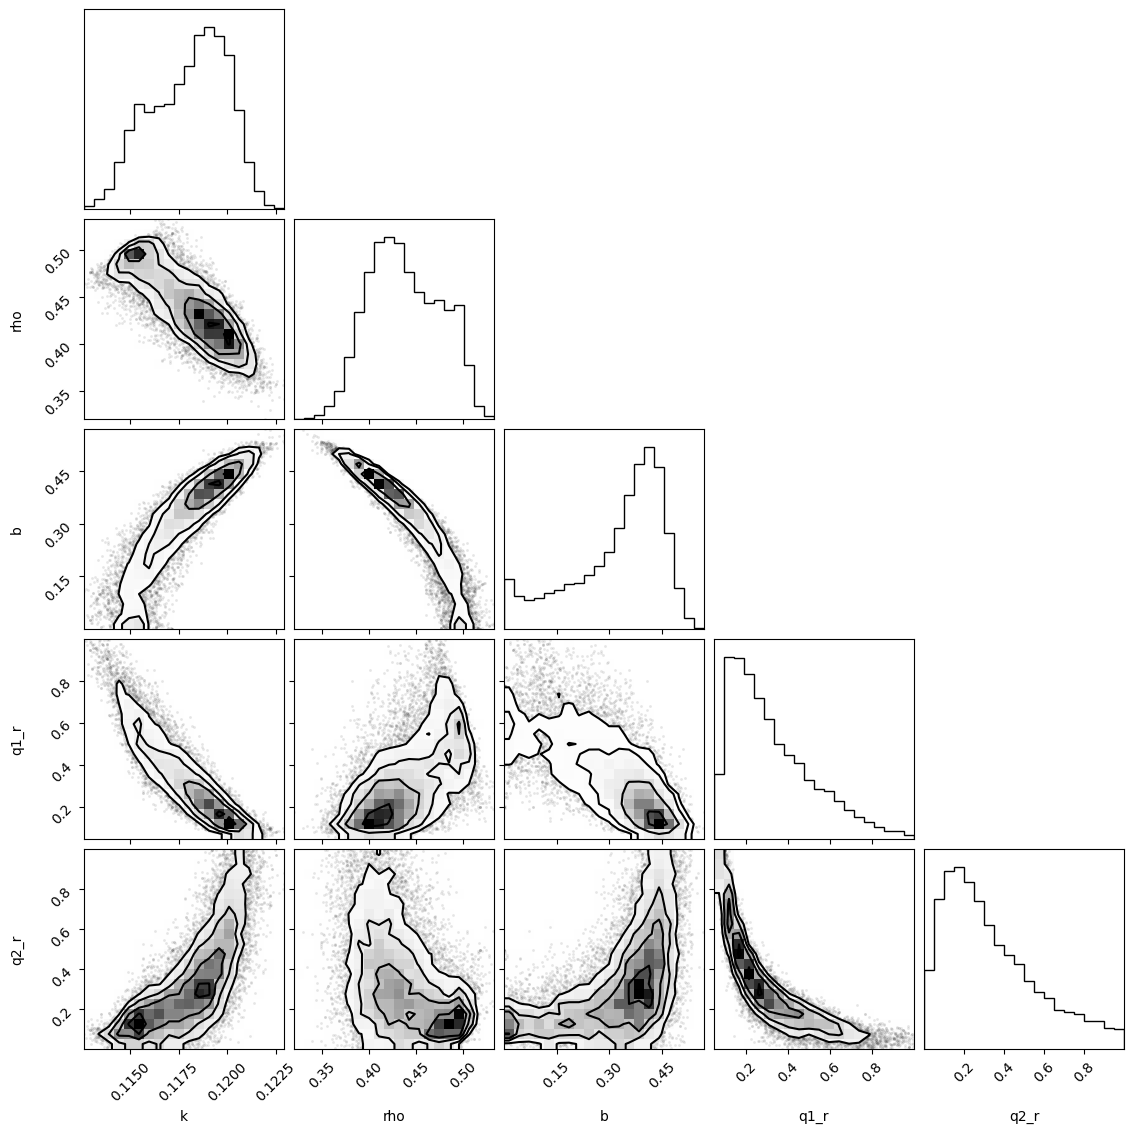

In [18]:
ccols = ['k', 'rho', 'b', 'q1_r', 'q2_r']
corner(df[ccols].values, labels=ccols);

### <span style="color:darkblue">Questions and exercises</span>

1. Estimate the radius of the planet using the planet-star radius ratio (k) and the stellar radius (that you need to find from somewhere) Give the answer in Jupiter radii.

Planet radius: 1.921 + 0.027 / - 0.041 [R_jup]


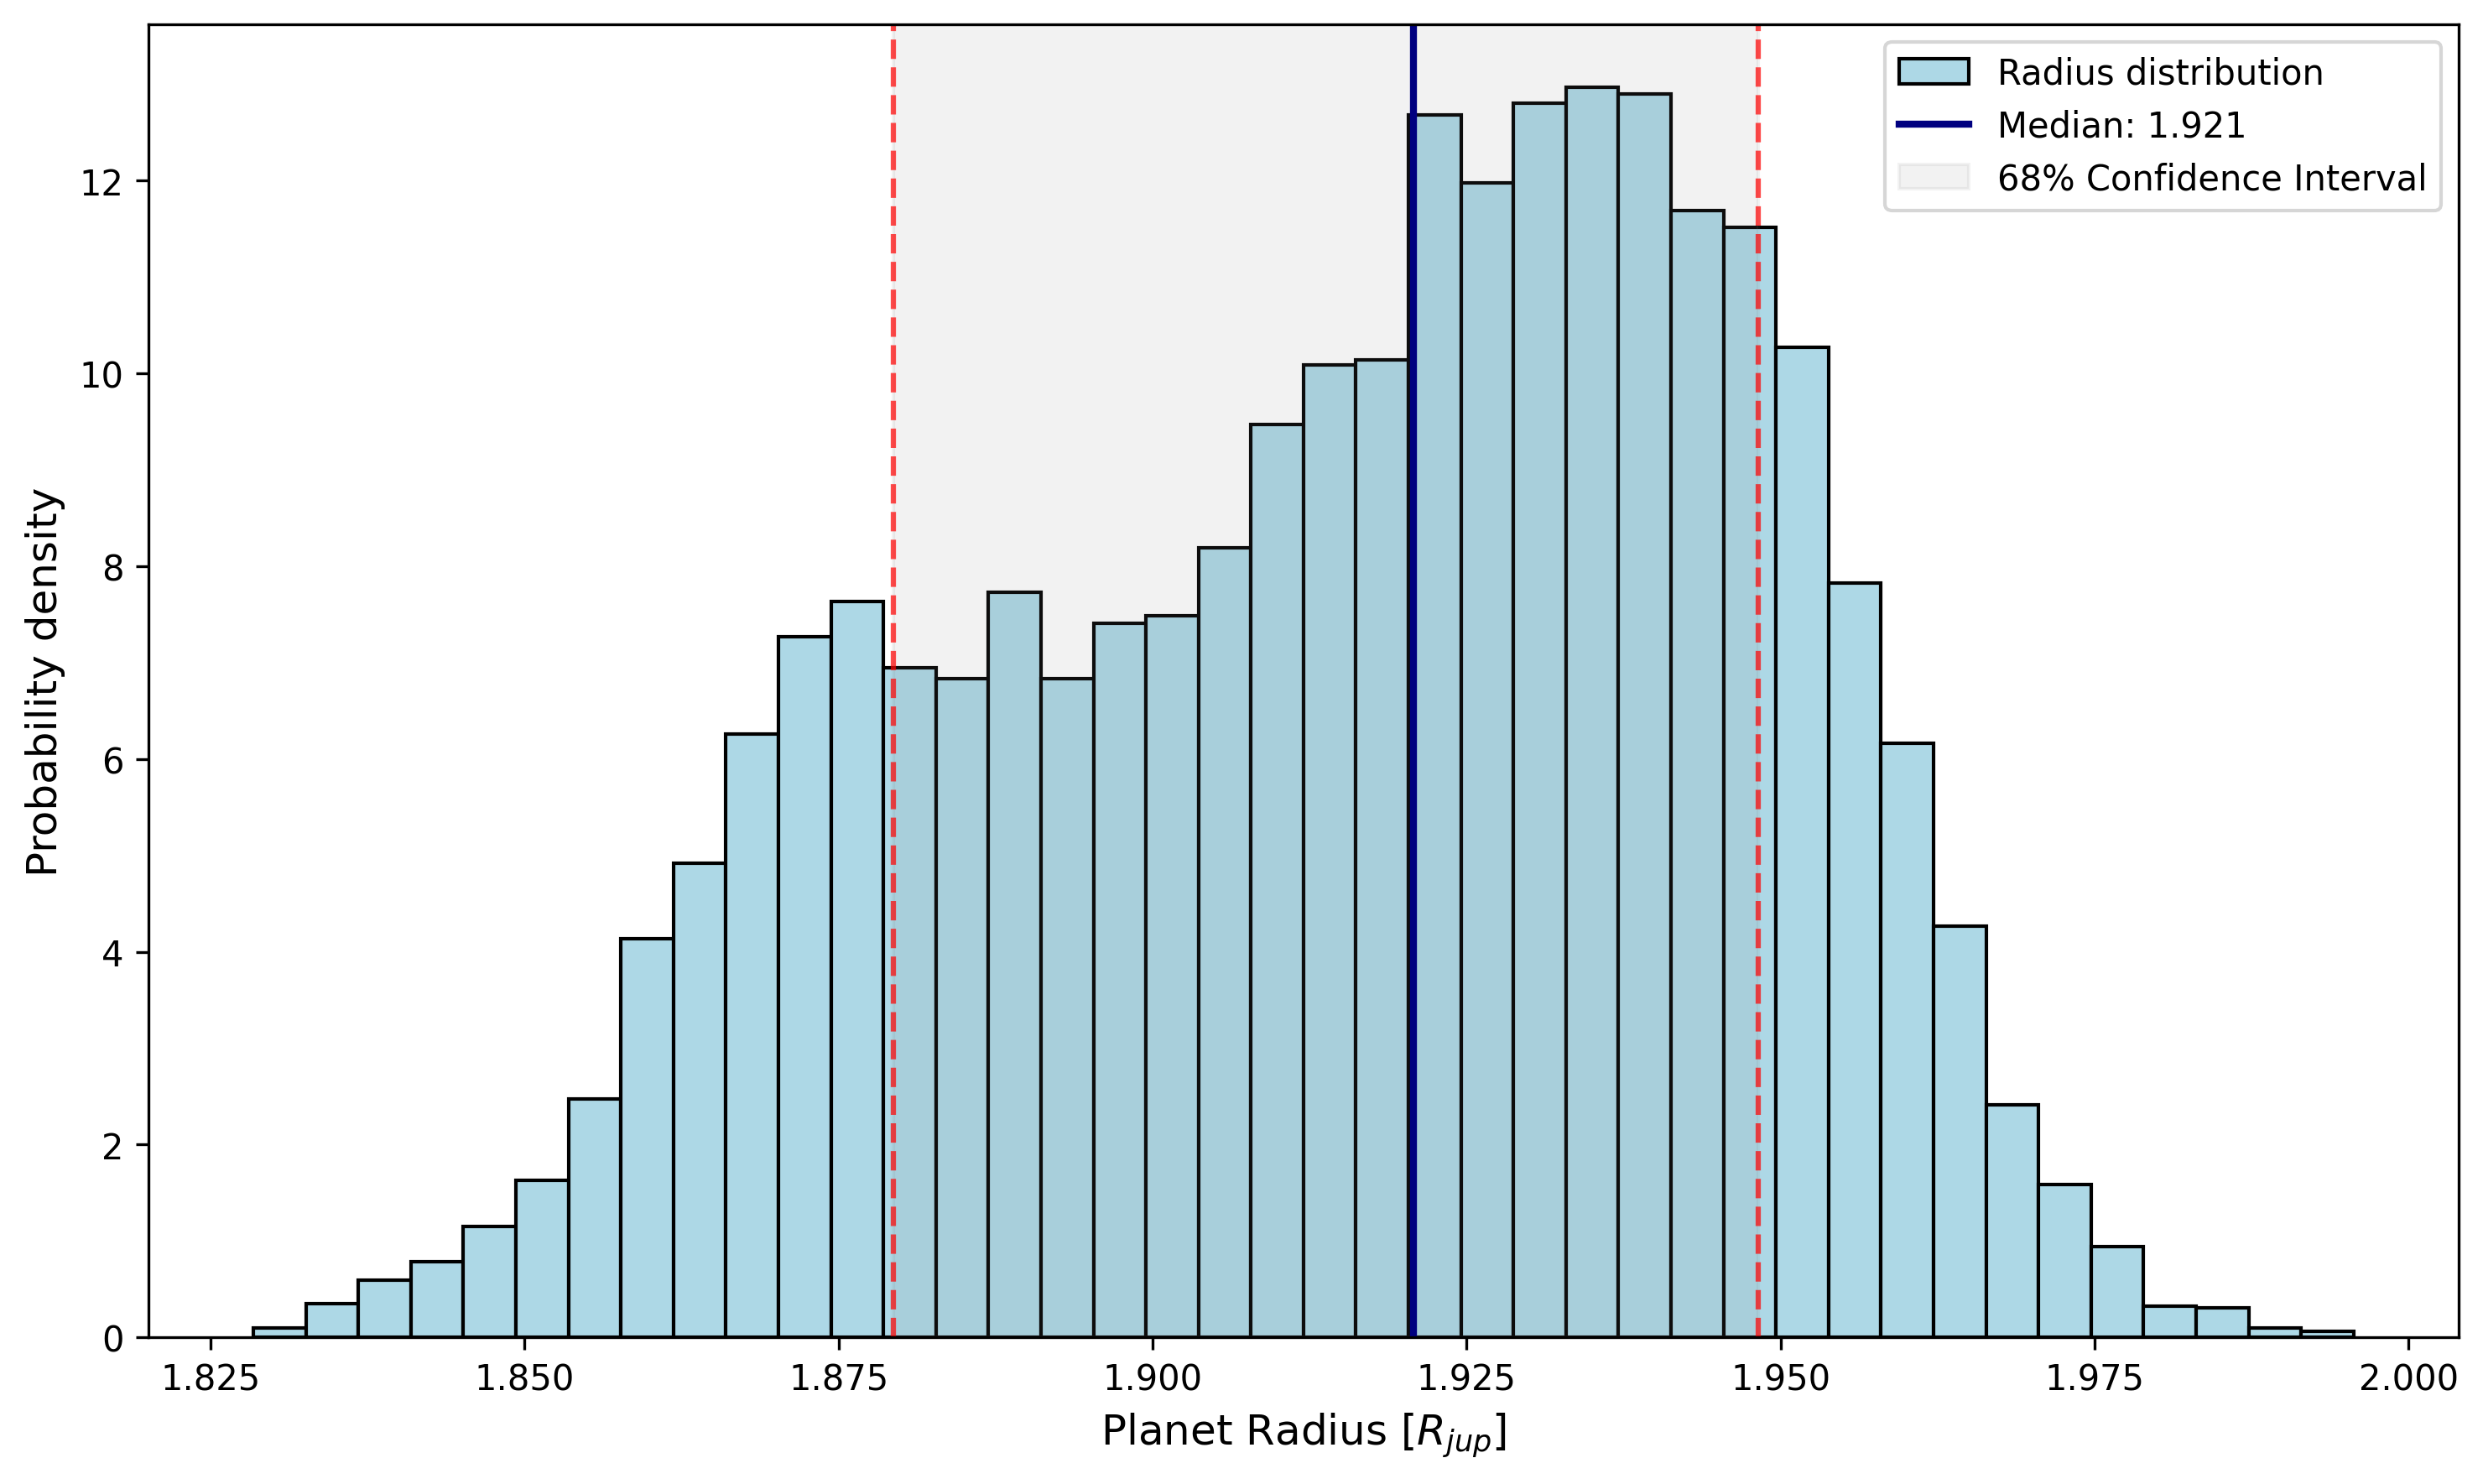

In [19]:
import numpy as np
import matplotlib.pyplot as plt

#First we extract the values of the k parameter
k_samples = lpf.posterior_samples()['k'].values

#Then we set the radius of the star
r_star = 1.631  # in solar radius
rsun_to_rjup = 9.954 #then we define the conversion between solar radius to jupyter radius

#We calculate the value for the radios and set the statistics
rp_samples = k_samples * r_star * rsun_to_rjup

rp_med = np.median(rp_samples)
rp_low, rp_high = np.percentile(rp_samples, [16, 84])

print(f"Planet radius: {rp_med:.3f} + {rp_high-rp_med:.3f} / - {rp_med-rp_low:.3f} [R_jup]")


#We plot the radius distribution
plt.figure(figsize=(10, 6), dpi=300)

n, bins, patches = plt.hist(rp_samples, bins=40, density=True, 
                            color='lightblue', edgecolor='black', 
                            label='Radius distribution')

plt.axvline(rp_med, color='navy', linestyle='-', linewidth=2, 
            label=f'Median: {rp_med:.3f}')
plt.axvline(rp_low, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axvline(rp_high, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

plt.axvspan(rp_low, rp_high, color='grey', alpha=0.1, 
            label='68% Confidence Interval')

plt.xlabel(r'Planet Radius [$R_{jup}$]', fontsize=12)
plt.ylabel('Probability density', fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

2. Estimate the planet's bulk density based on the radius posterior and exercise 1 minimum mass estimate. Include the minimum mass estimate's uncertainty into the calculation.

WASP-12b density: 0.238 g / cm3 + 0.016 / - 0.010 g/cm^3


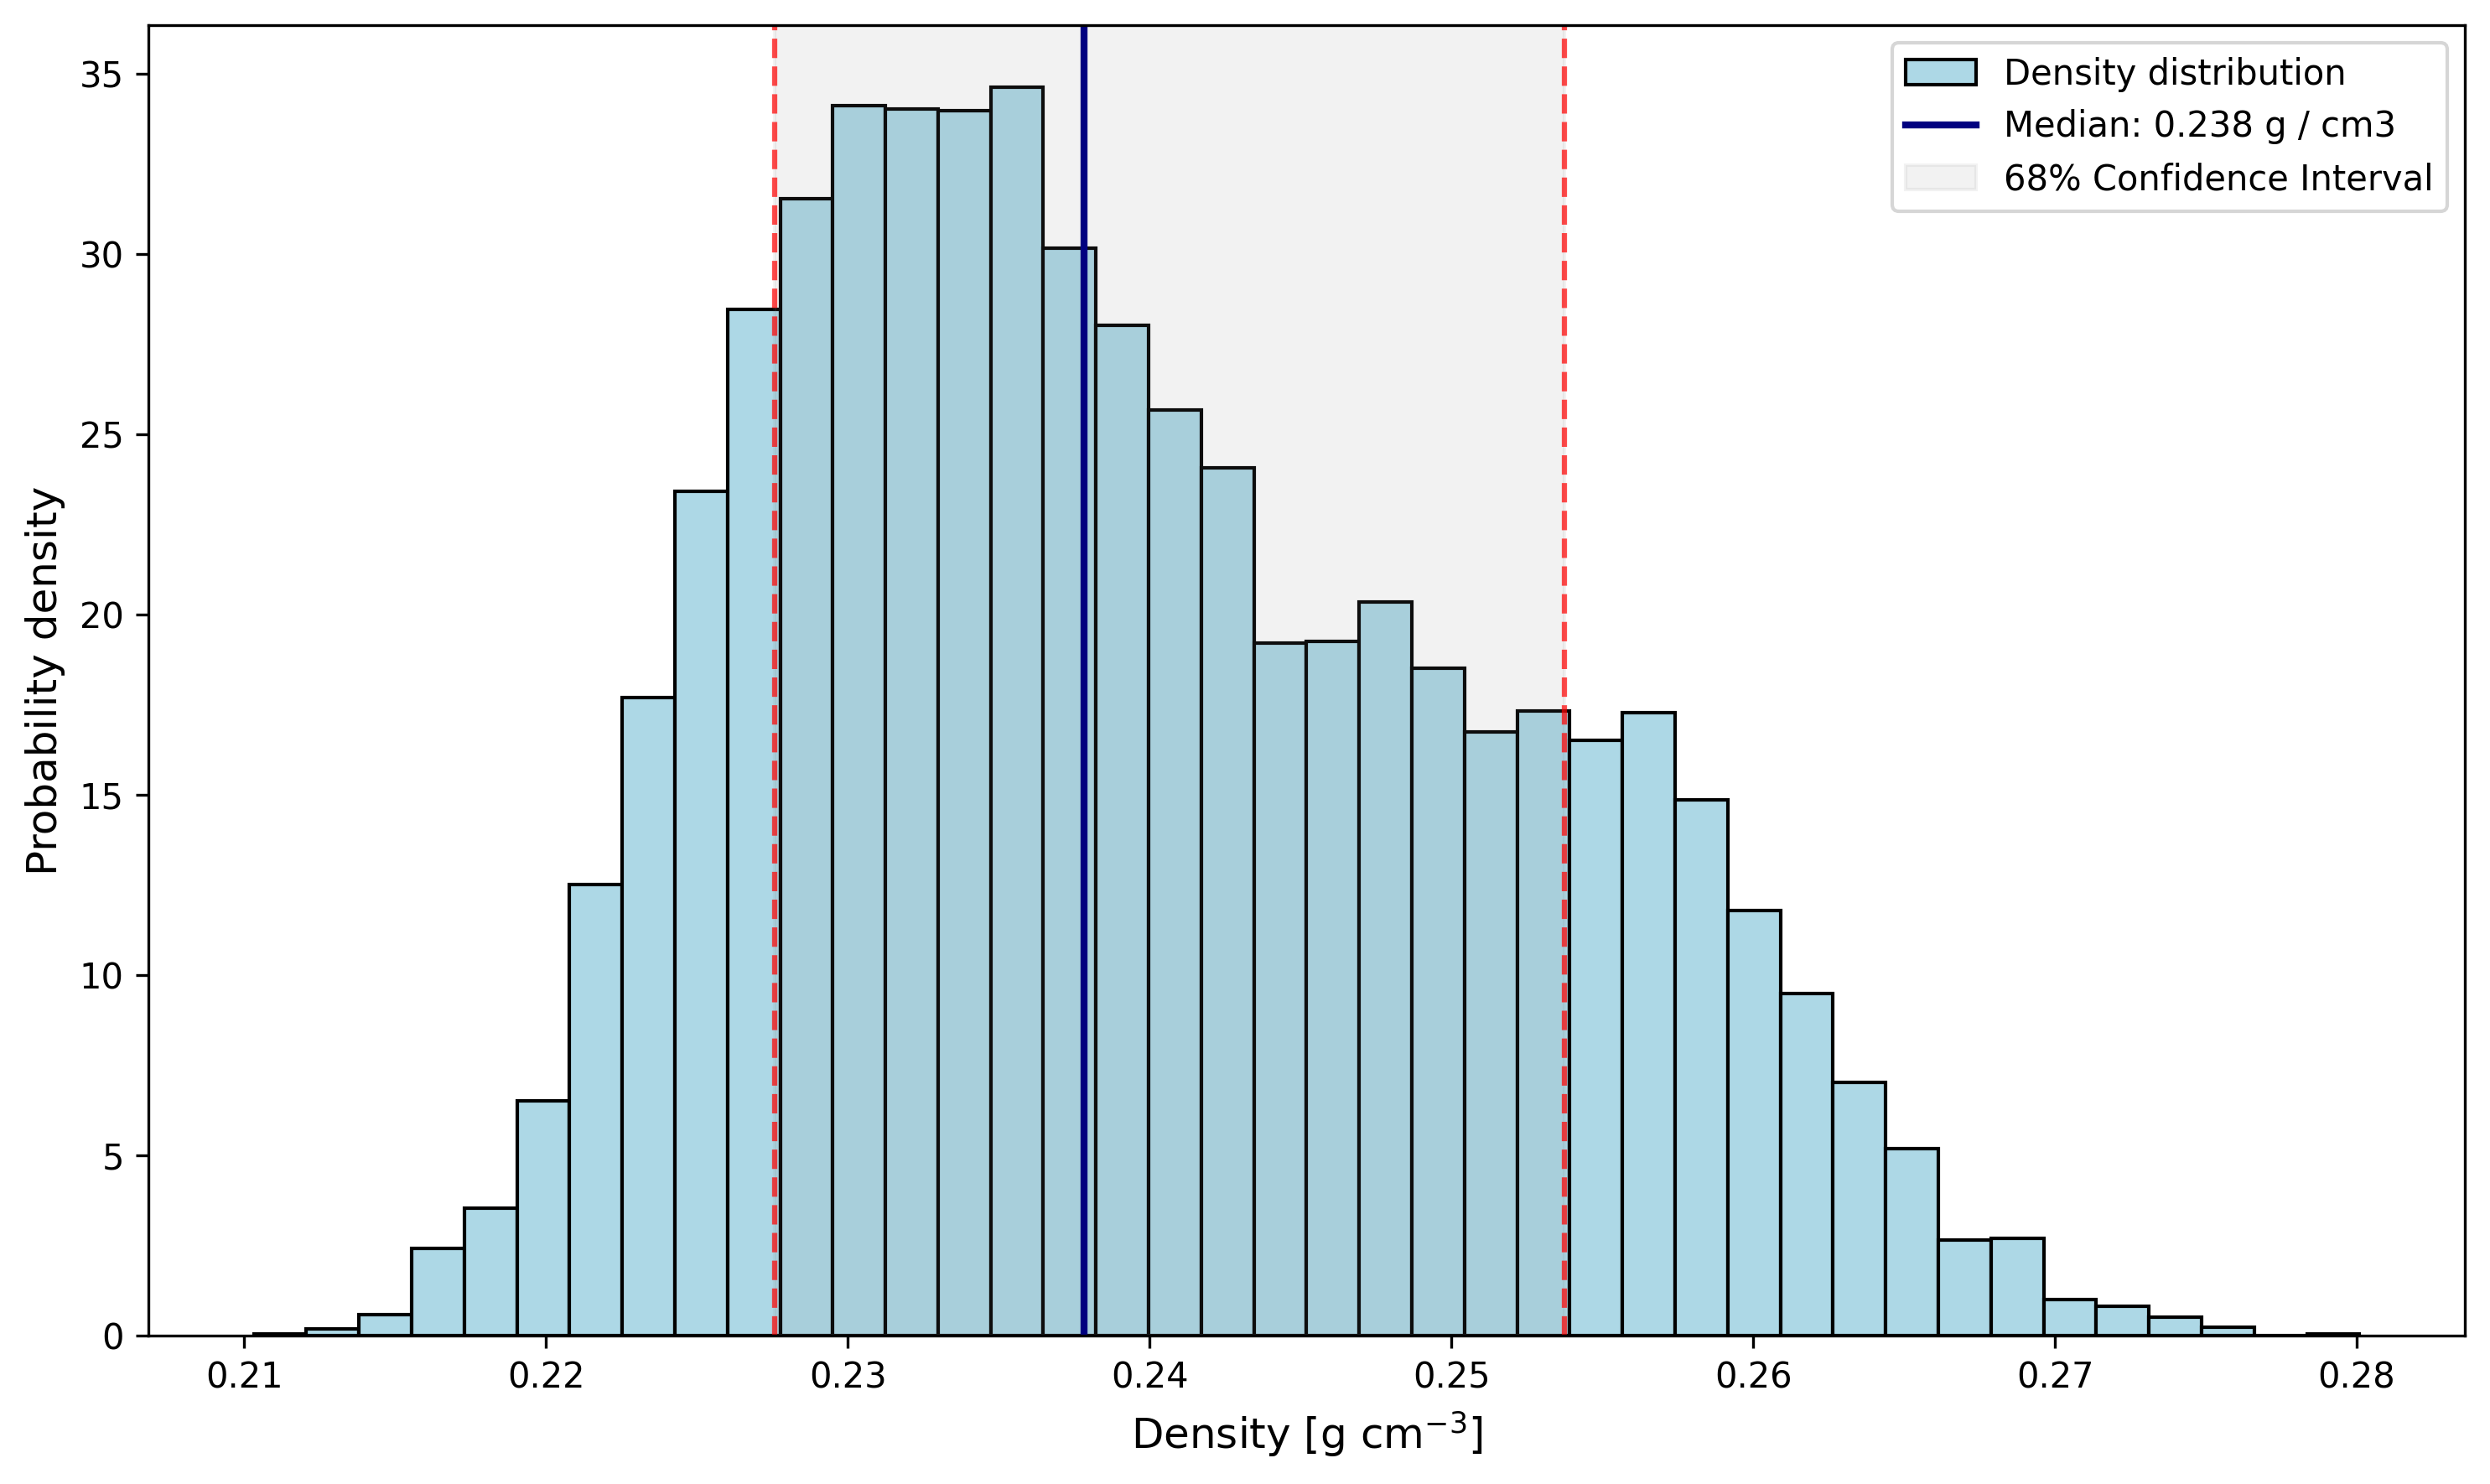

In [20]:
from astropy import units as u
from astropy import constants as c

# We create a normal distribution for the mass with the mean and std coming from ex. 1
mp_mean = 1.358
mp_std = 0.012
mp_samples = np.random.normal(mp_mean, mp_std, size=len(rp_samples)) * u.M_jup #we convert it to Jupiter masses

#Then we calculate the volume and some statistics
vol_samples = (4/3) * np.pi * rp_samples**3 * (u.R_jup)**3
rho_samples = (mp_samples / vol_samples).to(u.g / u.cm**3)

rho_med = np.median(rho_samples)
rho_16, rho_84 = np.percentile(rho_samples.value, [16, 84])

print(f"WASP-12b density: {rho_med:.3f} + {rho_84-rho_med.value:.3f} / - {rho_med.value-rho_16:.3f} g/cm^3")

plt.figure(figsize=(10, 6), dpi=300)

#We plot the density distribution
n, bins, patches = plt.hist(rho_samples.value, bins=40, density=True, 
                            color='lightblue', edgecolor='black', 
                            label='Density distribution')

# Then we add the confidence intervals for the density and the median
plt.axvline(rho_med.value, color='navy', linestyle='-', linewidth=2, label=f'Median: {rho_med:.3f}')
plt.axvline(rho_16, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axvline(rho_84, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

plt.axvspan(rho_16, rho_84, color='grey', alpha=0.1, label='68% Confidence Interval')

plt.xlabel(r'Density [g cm$^{-3}$]', fontsize=12)
plt.ylabel('Probability density', fontsize=12)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

3. Why can we use the minimum mass estimate from RVs as a true mass estimate after a transit observation? Would there be better ways to estimate planetary properties than by modelling RVs and photometry separately?

- We can use the minimum mass ($\rm M_p \ sin(i)$) from radial velocity (RV) observations as the true mass because the detection of a transit confirms that the system is viewed nearly edge-on. In transiting systems, the orbital inclination ($i$) must be close to $90^\circ$, which implies that $\sin i \approx 1$ and, consequently, $M_{true} \approx M_{min}$. 
Regarding planetary property estimation, a superior approach to modeling RVs and photometry separately is joint modelling (simultaneous fitting). This method is better because it accounts for the correlations between parameters shared by both datasets, such as the orbital period, eccentricity, and time of periastron, ensuring physically consistent results and providing more accurate uncertainty estimates by utilizing the full information available in both datasets simultaneously.
   
4. What can you say about WASP-12b as a planet based on its orbirtal period, radius, mass, and bulk density?

Based on the parameters derived from the analysis, WASP-12b is an extreme example of an inflated Hot Jupiter, because it shows:

* **Extreme Proximity:** Its exceptionally short orbital period ($\approx 1.09 \ [\rm days]$) indicates that the planet orbits dangerously close to its host star. This proximity subjects the planet to intense stellar radiation and massive tidal forces.
* **Thermal Inflation:** While its mass is only about 40% greater than Jupiter's ($\approx 1.4 \ \rm [M_{Jup}]$), its radius is nearly twice as large ($\approx 1.9 \ \rm[R_{Jup}]$). This "puffy" nature is a result of thermal inflation, where the extreme heat from the star deposited into the planet's interior prevents it from cooling and contracting, causing the atmosphere to expand significantly.
* **Low Bulk Density:** Consequently, its bulk density is remarkably low ($\approx 0.24 \ \rm[g \ cm^{-3}]$), which is less than a third of the density of water and significantly lower than any planet in our Solar System.

5. Compare the stellar density ($\rho$) estimated from the transit modelling to the theoretical stellar density for a WASP-12-like star.

The stellar density estimated directly from the transit model (median value from the MCMC) is approximately $\approx 0.439 \pm 0.03 \ \rm [g \ cm^{-3}]$. 

To calculate the theoretical density, we use the stellar mass ($M_\star \approx 1.35 \ \rm [M_\odot]$) and radius ($R_\star \approx 1.631 \ \rm [R_\odot]$):
$$\rho_{\text{theo}} = \frac{M_\star}{V_\star} = \frac{1.35 \, M_\odot}{\frac{4}{3} \pi (1.631 \, R_\odot)^3} \times 1.408 \text{ g cm}^{-3} \approx 0.437 \rm [{g \ cm}^{-3}]$$

The model-derived stellar density ($\approx 0.439 \ \rm [g \ cm^{-3}]$) and the theoretical density ($\approx 0.437 \ \rm [g \ cm^{-3}]$) show a very high level of agreement. This confirms that the orbital parameters (specifically $a/R_\star$ and the period) are correctly constrained and physically consistent with the known properties of the star WASP-12.

6. From the plot above you can see that many of the parameters are correlated with each other. What does this mean in practice?

These correlations (parameter degeneracies) mean that the model cannot uniquely determine one parameter without considering the values of the others. 

Specifically:
* **Interdependency:** A change in one parameter (such as increasing the impact parameter $b$) can be compensated by a change in another (like increasing the planet-to-star radius ratio $k$) to produce an almost identical light curve.
* **Uncertainty Estimation:** These correlations are the reason why we see "ellipses" in the corner plot. They indicate that the uncertainties in our parameters are linked.
* **Robustness:** Using MCMC allows us to marginalize over these correlations, providing realistic error bars that account for the fact that we don't know the "true" value of any single parameter in isolation, but rather a probability distribution of how they work together to fit the observed data.


---
<center>&copy;2026 Hannu Parviainen</center>